<a href="https://colab.research.google.com/github/Sarah-0405/Cold_Spots_Bayern/blob/main/W%C3%BCrzburg_Validierung_kleineres_Untersuchunsgebiet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Validierung der Cold Spots/ Test bei unterschiedlichem Untersuchungsgebiet**

am Beispiel von Würzburg (2019-2024) schauen, ob es sinnvoll ist, nur bewohnte Gebiete (mit etwas Puffer) in Cold-Spot-Berechnung mit einzubeziehen

zb nur rechtsseitig des Mains oder nur die Zensus-Gitterzellen, die bewohnt sind



Vorgehen:
1. Zensus-Gitterzellen laden
2. LST-Geodataframes laden und Gi* Analyse nur für Gitterzellen und zb 100m-Puffer berechnen (noch überlegen welcher Puffer urbane Grünflächen am ehesten mit einschließt)
3. Cold Spots klassifizieren auf Basis neuer Gi*-Ergebnisse
4. Visualisieren und visueller Check: Ringpark?

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Geodataframe mit den LST-Werten 2019-2024 laden

In [2]:
import geopandas as gpd

In [3]:
# Definieren Sie den Pfad, von dem die Datei geladen werden soll
# Stellen Sie sicher, dass dies mit dem Pfad übereinstimmt, unter dem Sie die Datei gespeichert haben
input_path_averaged_gdf = "/content/drive/MyDrive/Cold Spots Bayern/averaged_lst_per_pixel_per_city_allyears.geojson"

try:
    # Laden Sie den GeoDataFrame aus der GeoJSON-Datei
    loaded_averaged_lst_gdf = gpd.read_file(input_path_averaged_gdf)
    print(f"GeoDataFrame erfolgreich geladen von: {input_path_averaged_gdf}")
    print(f"Anzahl der Einträge im geladenen GeoDataFrame: {len(loaded_averaged_lst_gdf)}")
    display(loaded_averaged_lst_gdf.head())

except Exception as e:
    print(f"Fehler beim Laden des GeoDataFrames von {input_path_averaged_gdf}: {e}")
    print("Bitte überprüfen Sie den Dateipfad und stellen Sie sicher, dass die Datei existiert.")

# Nun können Sie mit 'loaded_averaged_lst_gdf' weiterarbeiten
# Zum Beispiel können Sie es in city_averaged_gdfs aufteilen oder direkt verwenden
# loaded_averaged_lst_gdf sollte die gleiche Struktur wie 'averaged_lst_per_pixel_per_city' haben

GeoDataFrame erfolgreich geladen von: /content/drive/MyDrive/Cold Spots Bayern/averaged_lst_per_pixel_per_city_allyears.geojson
Anzahl der Einträge im geladenen GeoDataFrame: 1992069


,city,avg_summer_LST_Celsius,geometry
0,Aschaffenburg,25.827932,POINT (9.23257 49.93527)
1,Aschaffenburg,25.828958,POINT (9.2355 49.935)
2,Aschaffenburg,25.846390,POINT (9.2355 49.93527)
3,Aschaffenburg,25.713771,POINT (9.23591 49.935)
4,Aschaffenburg,25.751711,POINT (9.23591 49.93527)


##Würzburg Filtern

In [12]:
# Filtern Sie das GeoDataFrame für die Stadt Würzburg
wuerzburg_gdf = loaded_averaged_lst_gdf[loaded_averaged_lst_gdf['city'] == 'Würzburg'].copy()

print(f"Anzahl der Einträge für Würzburg: {len(wuerzburg_gdf)}")
display(wuerzburg_gdf.head())

Anzahl der Einträge für Würzburg: 89251


,city,avg_summer_LST_Celsius,geometry
1902818,Würzburg,30.380963,POINT (9.87495 49.81132)
1902819,Würzburg,28.427906,POINT (9.87454 49.81132)
1902820,Würzburg,32.586269,POINT (9.87496 49.81159)
1902821,Würzburg,30.202087,POINT (9.87454 49.81159)
1902822,Würzburg,28.828042,POINT (9.87412 49.8116)


## Zensus-Gitterzellen laden und auf Würzburg zuschneiden

In [13]:
import pandas as pd

In [8]:
zensus_path = gpd.read_file("/content/drive/MyDrive/Cold Spots Bayern/Kopie von Zensus2022_Bevoelkerungszahl_100m-Gitter.csv")

In [14]:
print(zensus_path.head())

                   GITTER_ID_100m x_mp_100m y_mp_100m Einwohner
0  CRS3035RES100mN2689100E4337000   4337050   2689150         4
1  CRS3035RES100mN2689100E4341100   4341150   2689150        11
2  CRS3035RES100mN2690800E4341200   4341250   2690850         4
3  CRS3035RES100mN2691200E4341200   4341250   2691250        12
4  CRS3035RES100mN2691300E4341200   4341250   2691350         3


In [15]:
bayern_grenzen_path = ("/content/drive/MyDrive/Cold Spots Bayern/grenzen_ueber_50tsd.gpkg")

In [16]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Annahme: CSV enthält Spalten "x_mp_100m" und "y_mp_100m" für die Koordinaten
# We already have zensus_path loaded as a DataFrame

print("Spaltennamen in der Zensus DataFrame:", zensus_path.columns)

# Geometrie aus den Koordinaten erstellen und CRS auf EPSG:3035 setzen
# Ensure x_mp_100m and y_mp_100m are treated as correct coordinates for EPSG:3035
gitter_gdf = gpd.GeoDataFrame(
    zensus_path.copy(), # Use a copy to avoid modifying the original DataFrame
    geometry=gpd.points_from_xy(zensus_path.x_mp_100m, zensus_path.y_mp_100m),
    crs="EPSG:3035"
)

# Schritt 2: Würzburg Grenze aus bayern_grenzen_path laden und extrahieren
# We already have bayern_grenzen_path defined
bayern_grenzen_gdf = gpd.read_file(bayern_grenzen_path)

# Filter for Würzburg's boundary assuming 'name' column contains the municipality name
wuerzburg_grenze_gdf = bayern_grenzen_gdf[bayern_grenzen_gdf['name'] == 'Würzburg'].copy()

if wuerzburg_grenze_gdf.empty:
    print("Würzburg boundary not found in the bayern_grenzen_path file.")
else:
    # Schritt 3: Prüfen, ob beide Layer dasselbe CRS verwenden und ggf. reprojizieren
    # Reproject Würzburg boundary to match the zensus data's CRS (EPSG:3035)
    if gitter_gdf.crs != wuerzburg_grenze_gdf.crs:
        print(f"Reprojecting Würzburg boundary from {wuerzburg_grenze_gdf.crs} to {gitter_gdf.crs}")
        wuerzburg_grenze_gdf = wuerzburg_grenze_gdf.to_crs(gitter_gdf.crs)

    # Ensure wuerzburg_grenze_gdf has a valid geometry for union_all
    if not wuerzburg_grenze_gdf.is_empty.all():
        # Step 4: Clip the grid cells to the city boundary
        # Use sjoin for potentially better performance with many points
        gitter_in_stadt = gpd.sjoin(gitter_gdf, wuerzburg_grenze_gdf, predicate='within', how='inner')

        print(f"Anzahl der Gitterzellen innerhalb von Würzburg: {len(gitter_in_stadt)}")
        display(gitter_in_stadt.head())

        # Step 5: Save the result
        output_path_wuerzburg_zensus = "gitterzellen_wuerzburg.geojson" # Using GeoJSON for spatial data
        gitter_in_stadt.to_file(output_path_wuerzburg_zensus, driver='GeoJSON')
        print(f"Ergebnis gespeichert: {output_path_wuerzburg_zensus}")
    else:
        print("Würzburg boundary GeoDataFrame is empty or contains no valid geometries after reprojection.")

Spaltennamen in der Zensus DataFrame: Index(['GITTER_ID_100m', 'x_mp_100m', 'y_mp_100m', 'Einwohner'], dtype='object')
Reprojecting Würzburg boundary from EPSG:4326 to EPSG:3035
Anzahl der Gitterzellen innerhalb von Würzburg: 2559


,GITTER_ID_100m,x_mp_100m,y_mp_100m,Einwohner,geometry,index_right,bbox_west,bbox_south,bbox_east,bbox_north,...,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
903284,CRS3035RES100mN2955900E4318300,4318350,2955950,3,POINT (4318350 2955950),5,9.871628,49.710684,10.014429,49.845462,...,62464,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany"
903285,CRS3035RES100mN2955900E4318800,4318850,2955950,4,POINT (4318850 2955950),5,9.871628,49.710684,10.014429,49.845462,...,62464,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany"
903636,CRS3035RES100mN2956000E4318200,4318250,2956050,12,POINT (4318250 2956050),5,9.871628,49.710684,10.014429,49.845462,...,62464,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany"
903637,CRS3035RES100mN2956000E4318300,4318350,2956050,13,POINT (4318350 2956050),5,9.871628,49.710684,10.014429,49.845462,...,62464,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany"
903638,CRS3035RES100mN2956000E4318800,4318850,2956050,8,POINT (4318850 2956050),5,9.871628,49.710684,10.014429,49.845462,...,62464,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany"


Ergebnis gespeichert: gitterzellen_wuerzburg.geojson


In [17]:
gitterzellen_wuerzburg = gpd.read_file("/content/drive/MyDrive/Cold Spots Bayern/Zensus/gitterzellen_wuerzburg.geojson")
display(gitterzellen_wuerzburg)

,GITTER_ID_100m,x_mp_100m,y_mp_100m,Einwohner,index_right,bbox_west,bbox_south,bbox_east,bbox_north,place_id,...,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
0,CRS3035RES100mN2955900E4318300,4318350,2955950,3,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany",POINT (4318350 2955950)
1,CRS3035RES100mN2955900E4318800,4318850,2955950,4,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany",POINT (4318850 2955950)
2,CRS3035RES100mN2956000E4318200,4318250,2956050,12,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany",POINT (4318250 2956050)
3,CRS3035RES100mN2956000E4318300,4318350,2956050,13,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany",POINT (4318350 2956050)
4,CRS3035RES100mN2956000E4318800,4318850,2956050,8,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany",POINT (4318850 2956050)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2554,CRS3035RES100mN2969000E4317900,4317950,2969050,3,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany",POINT (4317950 2969050)
2555,CRS3035RES100mN2969100E4317900,4317950,2969150,3,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany",POINT (4317950 2969150)
2556,CRS3035RES100mN2969200E4317700,4317750,2969250,3,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany",POINT (4317750 2969250)
2557,CRS3035RES100mN2969300E4318100,4318150,2969350,7,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany",POINT (4318150 2969350)


## Visualisieren

Created 2559 square grid cell polygons.


,GITTER_ID_100m,x_mp_100m,y_mp_100m,Einwohner,index_right,bbox_west,bbox_south,bbox_east,bbox_north,place_id,...,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
0,CRS3035RES100mN2955900E4318300,4318350,2955950,3,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96256 49.71576, 9.96394 49.71575, ..."
1,CRS3035RES100mN2955900E4318800,4318850,2955950,4,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96949 49.71576, 9.97088 49.71575, ..."
2,CRS3035RES100mN2956000E4318200,4318250,2956050,12,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96117 49.71666, 9.96256 49.71665, ..."
3,CRS3035RES100mN2956000E4318300,4318350,2956050,13,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96256 49.71666, 9.96394 49.71665, ..."
4,CRS3035RES100mN2956000E4318800,4318850,2956050,8,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96949 49.71666, 9.97088 49.71665, ..."



--- Debugging Data after reprojection before plotting ---
grid_cells_4326 head:


,GITTER_ID_100m,x_mp_100m,y_mp_100m,Einwohner,index_right,bbox_west,bbox_south,bbox_east,bbox_north,place_id,...,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
0,CRS3035RES100mN2955900E4318300,4318350,2955950,3,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96256 49.71576, 9.96394 49.71575, ..."
1,CRS3035RES100mN2955900E4318800,4318850,2955950,4,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96949 49.71576, 9.97088 49.71575, ..."
2,CRS3035RES100mN2956000E4318200,4318250,2956050,12,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96117 49.71666, 9.96256 49.71665, ..."
3,CRS3035RES100mN2956000E4318300,4318350,2956050,13,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96256 49.71666, 9.96394 49.71665, ..."
4,CRS3035RES100mN2956000E4318800,4318850,2956050,8,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96949 49.71666, 9.97088 49.71665, ..."



grid_cells_4326 CRS: EPSG:4326

grid_cells_4326 total bounds: [ 9.87508121 49.71574963 10.00417589 49.83805207]

wuerzburg_grenze_4326 head:


,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
5,9.871628,49.710684,10.014429,49.845462,114380407,relation,62464,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","MULTIPOLYGON (((9.87163 49.79715, 9.87167 49.7..."



wuerzburg_grenze_4326 CRS: EPSG:4326

wuerzburg_grenze_4326 total bounds: [ 9.8716285 49.7106843 10.0144286 49.8454619]
--- End Debugging ---


/tmp/ipython-input-199188352.py:76: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipython-input-199188352.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


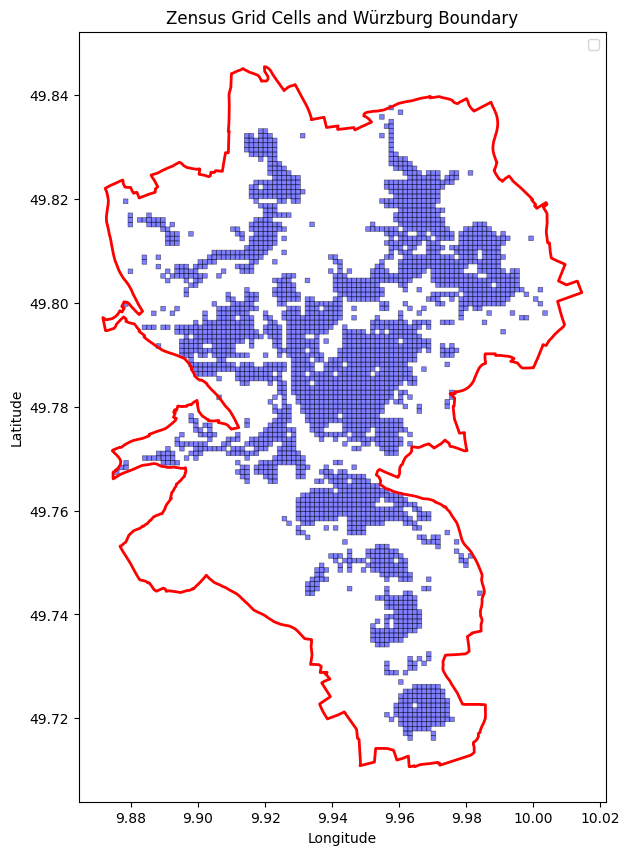

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon

# Assuming gitterzellen_wuerzburg is loaded and contains the zensus data points in EPSG:4326

# Reproject gitterzellen_wuerzburg to a projected CRS (e.g., EPSG:32632 - WGS 84 / UTM zone 32N)
# This CRS uses meters as units, which is necessary for creating a 100x100m grid.
gitterzellen_wuerzburg_projected = gitterzellen_wuerzburg.to_crs(epsg=32632)

# Function to create a 100x100m square polygon centered at a point
def create_square_grid_cell(point, size=100):
    # Calculate half the size
    half_size = size / 2.0
    # Create a square polygon centered at the point
    # The coordinates are in the projected CRS (meters)
    polygon = Polygon([
        (point.x - half_size, point.y - half_size),
        (point.x + half_size, point.y - half_size),
        (point.x + half_size, point.y + half_size),
        (point.x - half_size, point.y + half_size),
        (point.x - half_size, point.y - half_size) # Close the polygon
    ])
    return polygon

# Create a new GeoDataFrame with square polygons
grid_cells_projected = gpd.GeoDataFrame(
    gitterzellen_wuerzburg_projected.drop(columns=['geometry']), # Keep original data columns
    geometry=gitterzellen_wuerzburg_projected.geometry.apply(create_square_grid_cell),
    crs=gitterzellen_wuerzburg_projected.crs # Set CRS to the projected CRS
)

# Reproject the grid cell polygons back to EPSG:4326 for visualization
grid_cells_4326 = grid_cells_projected.to_crs(epsg=4326)

print(f"Created {len(grid_cells_4326)} square grid cell polygons.")
display(grid_cells_4326.head())


# Assuming wuerzburg_grenze is already loaded and contains the Würzburg boundary in EPSG:4326

# --- Static Visualization using Geopandas and Matplotlib ---

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Reproject wuerzburg_grenze_gdf to EPSG:4326 for plotting
wuerzburg_grenze_4326 = wuerzburg_grenze_gdf.to_crs(epsg=4326)


# --- Debugging: Check data after reprojection before plotting ---
print("\n--- Debugging Data after reprojection before plotting ---")
print("grid_cells_4326 head:")
display(grid_cells_4326.head())
print("\ngrid_cells_4326 CRS:", grid_cells_4326.crs)
print("\ngrid_cells_4326 total bounds:", grid_cells_4326.total_bounds)

print("\nwuerzburg_grenze_4326 head:")
display(wuerzburg_grenze_4326.head())
print("\nwuerzburg_grenze_4326 CRS:", wuerzburg_grenze_4326.crs)
print("\nwuerzburg_grenze_4326 total bounds:", wuerzburg_grenze_4326.total_bounds)
print("--- End Debugging ---")


# Plot the grid cell polygons
grid_cells_4326.plot(ax=ax, color='blue', edgecolor='black', linewidth=0.5, alpha=0.5, label='Zensus Grid Cells (100m)')

# Plot the Würzburg boundary
wuerzburg_grenze_4326.plot(ax=ax, color='none', edgecolor='red', linewidth=2, label='Würzburg Boundary')

# Add title and labels
ax.set_title('Zensus Grid Cells and Würzburg Boundary')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add a legend
ax.legend()

# Display the plot
plt.show()

# LST-gdf auf Gitterzellen zuschneiden

es werden nur die Gitterzellen für die Cold Sppots und Gi* ANalyse verwendet, da dies die bewohnten Gebiete sind. Es wurde allerdings ein Puffer um die Gitterzellen erstellt (es wurden statt 100x100, 250x250xm große Gitterzellen erstellt)

Puffer zu groß/klein ? schließt auch nicht alle Teile des Ringparks mit ein

In [26]:
import geopandas as gpd
from shapely.geometry import Point, Polygon

# Assuming gitterzellen_wuerzburg is loaded and contains the zensus data points (in EPSG:4326 based on previous steps)

# Step 1: Reproject gitterzellen_wuerzburg to a projected CRS for accurate buffering
# Using EPSG:32632 (WGS 84 / UTM zone 32N) which is suitable for Würzburg and uses meters.
gitterzellen_wuerzburg_projected_for_buffer = gitterzellen_wuerzburg.to_crs(epsg=32632)

# Function to create a square polygon centered at a point with a specified size
def create_square_grid_cell(point, size=250):
    # Calculate half the size
    half_size = size / 2.0
    # Create a square polygon centered at the point in the projected CRS
    polygon = Polygon([
        (point.x - half_size, point.y - half_size),
        (point.x + half_size, point.y - half_size),
        (point.x + half_size, point.y + half_size),
        (point.x - half_size, point.y + half_size),
        (point.x - half_size, point.y - half_size) # Close the polygon
    ])
    return polygon

# Step 2: Create a new GeoDataFrame with 250x250m square polygons
# Apply the function to each point geometry
grid_cells_250m_projected = gpd.GeoDataFrame(
    gitterzellen_wuerzburg_projected_for_buffer.drop(columns=['geometry']), # Keep original data columns
    geometry=gitterzellen_wuerzburg_projected_for_buffer.geometry.apply(lambda geom: create_square_grid_cell(geom, size=250)),
    crs=gitterzellen_wuerzburg_projected_for_buffer.crs # Set CRS to the projected CRS
)

# Step 3: Reproject the 250m grid cell polygons back to EPSG:4326
grid_cells_250m_4326 = grid_cells_250m_projected.to_crs(epsg=4326)

print(f"Created {len(grid_cells_250m_4326)} square grid cell polygons (250m).")
display(grid_cells_250m_4326.head())

# Now grid_cells_250m_4326 is created and can be used in subsequent cells.

Created 2559 square grid cell polygons (250m).


,GITTER_ID_100m,x_mp_100m,y_mp_100m,Einwohner,index_right,bbox_west,bbox_south,bbox_east,bbox_north,place_id,...,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
0,CRS3035RES100mN2955900E4318300,4318350,2955950,3,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.9615 49.7151, 9.96497 49.71507, 9...."
1,CRS3035RES100mN2955900E4318800,4318850,2955950,4,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96844 49.7151, 9.9719 49.71507, 9...."
2,CRS3035RES100mN2956000E4318200,4318250,2956050,12,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96012 49.71599, 9.96358 49.71597, ..."
3,CRS3035RES100mN2956000E4318300,4318350,2956050,13,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.9615 49.71599, 9.96497 49.71597, 9..."
4,CRS3035RES100mN2956000E4318800,4318850,2956050,8,5,9.871628,49.710684,10.014429,49.845462,114380407,...,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.96844 49.716, 9.9719 49.71597, 9.9..."


Reprojecting wuerzburg_grenze_gdf to EPSG:4326 for plotting.


/tmp/ipython-input-2592439488.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipython-input-2592439488.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


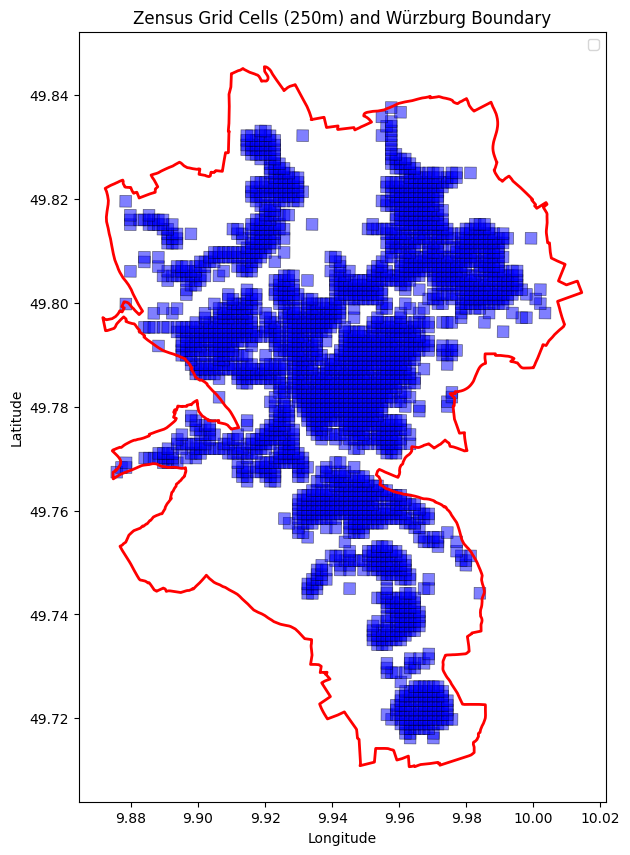

In [37]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Assuming grid_cells_250m_4326 and wuerzburg_grenze_gdf are loaded and in EPSG:4326

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the 250m grid cell polygons
grid_cells_250m_4326.plot(ax=ax, color='blue', edgecolor='black', linewidth=0.5, alpha=0.5, label='Zensus Grid Cells (250m)')

# Plot the Würzburg boundary (assuming it's already in EPSG:4326 or reprojecting it)
# Based on previous steps, wuerzburg_grenze_gdf should be available and in EPSG:4326
if wuerzburg_grenze_gdf.crs is None or wuerzburg_grenze_gdf.crs.to_string() != 'EPSG:4326':
     print("Reprojecting wuerzburg_grenze_gdf to EPSG:4326 for plotting.")
     wuerzburg_grenze_4326_plot = wuerzburg_grenze_gdf.to_crs(epsg=4326)
else:
    wuerzburg_grenze_4326_plot = wuerzburg_grenze_gdf


wuerzburg_grenze_4326_plot.plot(ax=ax, color='none', edgecolor='red', linewidth=2, label='Würzburg Boundary')


# Add title and labels
ax.set_title('Zensus Grid Cells (250m) and Würzburg Boundary')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add a legend
ax.legend()

# Display the plot
plt.show()

In [27]:
# Save the 250x250m grid cell GeoDataFrame to a file
output_path_250m_grid = "wuerzburg_grid_cells_250m.geojson"

try:
    grid_cells_250m_4326.to_file(output_path_250m_grid, driver='GeoJSON')
    print(f"250x250m grid cell GeoDataFrame saved successfully to: {output_path_250m_grid}")
except Exception as e:
    print(f"Error saving GeoDataFrame to {output_path_250m_grid}: {e}")
    print("Please check the path and permissions.")

250x250m grid cell GeoDataFrame saved successfully to: wuerzburg_grid_cells_250m.geojson


In [28]:
import geopandas as gpd

# Assuming grid_cells_250m_4326 (polygons) and wuerzburg_gdf (LST points) are loaded and in the same CRS (EPSG:4326)

# Drop the problematic 'index_right' column from grid_cells_250m_4326 if it exists
if 'index_right' in grid_cells_250m_4326.columns:
    grid_cells_250m_4326 = grid_cells_250m_4326.drop(columns=['index_right'])
    print("Dropped 'index_right' column from grid_cells_250m_4326.")


# Perform a spatial join to associate LST values with the 250x250m grid cells
# We use a 'left' join to keep all grid cells and add LST data that intersects them.
# 'intersects' predicate checks if the point falls within or touches the polygon boundary.
grid_cells_with_lst = gpd.sjoin(grid_cells_250m_4326, wuerzburg_gdf, predicate='intersects', how='left')

print(f"GeoDataFrame after spatial join with LST data: {len(grid_cells_with_lst)} entries.")
display(grid_cells_with_lst.head())

# Note: If a grid cell intersects with multiple LST points, it will appear multiple times
# in the resulting GeoDataFrame. You might want to aggregate the LST values per grid cell
# in a next step (e.g., calculate the mean LST for each grid cell).

Dropped 'index_right' column from grid_cells_250m_4326.
GeoDataFrame after spatial join with LST data: 172745 entries.


,GITTER_ID_100m,x_mp_100m,y_mp_100m,Einwohner,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,...,type,place_rank,importance,addresstype,name,display_name,geometry,index_right,city,avg_summer_LST_Celsius
0,CRS3035RES100mN2955900E4318300,4318350,2955950,3,9.871628,49.710684,10.014429,49.845462,114380407,relation,...,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.9615 49.7151, 9.96497 49.71507, 9....",1942129.0,Würzburg,27.771494
0,CRS3035RES100mN2955900E4318300,4318350,2955950,3,9.871628,49.710684,10.014429,49.845462,114380407,relation,...,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.9615 49.7151, 9.96497 49.71507, 9....",1942128.0,Würzburg,27.677879
0,CRS3035RES100mN2955900E4318300,4318350,2955950,3,9.871628,49.710684,10.014429,49.845462,114380407,relation,...,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.9615 49.7151, 9.96497 49.71507, 9....",1942131.0,Würzburg,28.532099
0,CRS3035RES100mN2955900E4318300,4318350,2955950,3,9.871628,49.710684,10.014429,49.845462,114380407,relation,...,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.9615 49.7151, 9.96497 49.71507, 9....",1942130.0,Würzburg,27.960815
0,CRS3035RES100mN2955900E4318300,4318350,2955950,3,9.871628,49.710684,10.014429,49.845462,114380407,relation,...,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","POLYGON ((9.9615 49.7151, 9.96497 49.71507, 9....",1942133.0,Würzburg,28.649166


der grid_cells_with_lst geodataframe enthält jetzt LST-Daten für die Gitterzellen

# KNN-Matrix erstellen

In [29]:
import geopandas as gpd
from libpysal.weights import KNN
import numpy as np

# Assuming grid_cells_with_lst is the result of the spatial join (cell 51d1c402)
# Assuming wuerzburg_gdf is the original GeoDataFrame of LST pixels

# Identify the unique indices of the LST pixels that intersected with the grid cells
# The 'index_right' column in grid_cells_with_lst contains the indices of the rows from wuerzburg_gdf
# that intersected with the grid cells. We need to drop NaN values from 'index_right' first
# as some grid cells might not have intersected any LST points (due to the 'left' join).
intersecting_lst_indices = grid_cells_with_lst['index_right'].dropna().unique().astype(int)

# Select these specific LST pixels from the original wuerzburg_gdf
# Use .loc to select rows based on index
lst_pixels_within_gridcells = wuerzburg_gdf.loc[intersecting_lst_indices].copy()

# Ensure the resulting GeoDataFrame has a defined CRS and valid geometries
if lst_pixels_within_gridcells.crs is None:
    # Assuming wuerzburg_gdf had a CRS, assign it to the filtered GeoDataFrame
    lst_pixels_within_gridcells.set_crs(wuerzburg_gdf.crs, inplace=True)

if not lst_pixels_within_gridcells.geometry.is_valid.all():
     print("Warning: Some geometries in lst_pixels_within_gridcells are invalid. Attempting to fix.")
     lst_pixels_within_gridcells['geometry'] = lst_pixels_within_gridcells.geometry.buffer(0) # Attempt to fix invalid geometries


print(f"Number of LST pixels within grid cells: {len(lst_pixels_within_gridcells)}")
display(lst_pixels_within_gridcells.head())


# --- Create KNN Matrix ---

# Drop rows with NaN geometry before creating KNN
lst_pixels_valid_geom = lst_pixels_within_gridcells.dropna(subset=['geometry']).copy()

# Extract coordinates from the geometry
# For point geometries, .geometry.x and .geometry.y give the coordinates
coords = np.vstack([lst_pixels_valid_geom.geometry.x, lst_pixels_valid_geom.geometry.y]).T


# Create the KNN spatial weights matrix for the filtered LST pixels
n_neighbors = 12
try:
    # Use the coordinates directly with the KNN constructor
    knn_weights_filtered_lst = KNN(coords, k=n_neighbors)
    print(f"\nKNN weights matrix created with {n_neighbors} neighbors for filtered LST pixels.")
    print("Number of observations in weights matrix:", knn_weights_filtered_lst.n)

    # info() method might not be available depending on libpysal version/object type
    # knn_weights_filtered_lst.info()

    # Optional: Summarize the weights
    # print("\nWeights summary:")
    # knn_weights_filtered_lst.summary()

except Exception as e:
    print(f"Error creating KNN matrix for filtered LST pixels: {e}")
    print("Please check the input coordinates and the number of neighbors.")

# The resulting knn_weights_filtered_lst matrix represents the spatial relationships between the LST pixels
# that are located within the 250x250m grid cells.

Number of LST pixels within grid cells: 44723


,city,avg_summer_LST_Celsius,geometry
1942129,Würzburg,27.771494,POINT (9.96228 49.71511)
1942128,Würzburg,27.677879,POINT (9.96186 49.71511)
1942131,Würzburg,28.532099,POINT (9.96311 49.7151)
1942130,Würzburg,27.960815,POINT (9.9627 49.7151)
1942133,Würzburg,28.649166,POINT (9.96312 49.71537)



KNN weights matrix created with 12 neighbors for filtered LST pixels.
Number of observations in weights matrix: 44723


/usr/local/lib/python3.11/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 13 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


# GI*-Analyse

In [30]:
!pip install pysal

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.6/141.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.1/248.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 25.8 MB/s eta 0:00:00
   ━━━━

In [31]:
import esda
import numpy as np
import pandas as pd

# Assuming lst_pixels_within_gridcells is the GeoDataFrame with filtered LST pixels and their values
# Assuming knn_weights_filtered_lst is the KNN spatial weights matrix created for these pixels

# Ensure the order of data matches the order of observations in the weights matrix
# The weights matrix was created from lst_pixels_valid_geom, which is a subset of lst_pixels_within_gridcells
# filtered for valid geometries. So, we should use lst_pixels_valid_geom for the analysis.
# Let's re-use lst_pixels_valid_geom from cell 5c31ccc8

# Extract the variable for analysis (LST values)
# Ensure the data is a pandas Series or NumPy array
y = lst_pixels_valid_geom['avg_summer_LST_Celsius'].values

# Perform Getis-Ord Gi* analysis
# The G_Local function computes Gi*
try:
    gi_star = esda.G_Local(y, knn_weights_filtered_lst)

    # The results are stored in the gi_star object
    # gi_star.Gs: Gi* statistic values
    # gi_star.p_sim: p-values based on simulation (recommended for inference)
    # gi_star.z_sim: Z-scores based on simulation

    print("\nGetis-Ord Gi* analysis performed.")
    print(f"Number of observations analyzed: {len(gi_star.Gs)}")

    # Add the Gi* results back to the GeoDataFrame
    # Ensure the results are aligned with the correct rows in the GeoDataFrame
    # gi_star.Gs, gi_star.p_sim, gi_star.z_sim are NumPy arrays, their order corresponds to the input data (y)
    # which came from lst_pixels_valid_geom.
    lst_pixels_valid_geom['gi_star'] = gi_star.Gs
    lst_pixels_valid_geom['gi_star_p_sim'] = gi_star.p_sim
    lst_pixels_valid_geom['gi_star_z_sim'] = gi_star.z_sim

    print("\nGi* results added to GeoDataFrame.")
    display(lst_pixels_valid_geom.head())

except Exception as e:
    print(f"Error performing Gi* analysis: {e}")
    print("Please check the input data (LST values) and the spatial weights matrix.")

# The lst_pixels_valid_geom GeoDataFrame now contains the Gi* results.
# The next step is typically to classify these results and visualize them.


Getis-Ord Gi* analysis performed.
Number of observations analyzed: 44723

Gi* results added to GeoDataFrame.


,city,avg_summer_LST_Celsius,geometry,gi_star,gi_star_p_sim,gi_star_z_sim
1942129,Würzburg,27.771494,POINT (9.96228 49.71511),0.000019,0.001,-4.758410
1942128,Würzburg,27.677879,POINT (9.96186 49.71511),0.000019,0.001,-4.842026
1942131,Würzburg,28.532099,POINT (9.96311 49.7151),0.000020,0.001,-4.044000
1942130,Würzburg,27.960815,POINT (9.9627 49.7151),0.000019,0.001,-4.528656
1942133,Würzburg,28.649166,POINT (9.96312 49.71537),0.000020,0.001,-3.975915


In [32]:
import geopandas as gpd
import numpy as np

# Assuming lst_pixels_valid_geom is the GeoDataFrame with LST values and Gi* results

# Define significance level
alpha = 0.05

# Classify pixels based on Gi* results and significance
# Add a new column for classification
lst_pixels_valid_geom['gi_star_classification'] = 'Not Significant'

# Classify Cold Spots: Negative Z-score and p-value <= alpha
lst_pixels_valid_geom.loc[
    (lst_pixels_valid_geom['gi_star_z_sim'] < 0) &
    (lst_pixels_valid_geom['gi_star_p_sim'] <= alpha),
    'gi_star_classification'
] = 'Cold Spot'

# Classify Hot Spots: Positive Z-score and p-value <= alpha
lst_pixels_valid_geom.loc[
    (lst_pixels_valid_geom['gi_star_z_sim'] > 0) &
    (lst_pixels_valid_geom['gi_star_p_sim'] <= alpha),
    'gi_star_classification'
] = 'Hot Spot'

print("Classification counts:")
print(lst_pixels_valid_geom['gi_star_classification'].value_counts())

# Filter to keep only Cold Spots
cold_spots_gdf = lst_pixels_valid_geom[lst_pixels_valid_geom['gi_star_classification'] == 'Cold Spot'].copy()

print(f"\nNumber of identified Cold Spots: {len(cold_spots_gdf)}")
display(cold_spots_gdf.head())

# Save the Cold Spots GeoDataFrame
output_path_cold_spots = "wuerzburg_cold_spots.geojson"

try:
    # Ensure all necessary columns are included
    cold_spots_gdf_to_save = cold_spots_gdf[['city', 'avg_summer_LST_Celsius', 'geometry',
                                             'gi_star', 'gi_star_p_sim', 'gi_star_z_sim',
                                             'gi_star_classification']].copy()

    cold_spots_gdf_to_save.to_file(output_path_cold_spots, driver='GeoJSON')
    print(f"\nCold Spots GeoDataFrame saved successfully to: {output_path_cold_spots}")
except Exception as e:
    print(f"Error saving Cold Spots GeoDataFrame to {output_path_cold_spots}: {e}")
    print("Please check the path and permissions.")

Classification counts:
gi_star_classification
Not Significant    16795
Hot Spot           14785
Cold Spot          13143
Name: count, dtype: int64

Number of identified Cold Spots: 13143


,city,avg_summer_LST_Celsius,geometry,gi_star,gi_star_p_sim,gi_star_z_sim,gi_star_classification
1942129,Würzburg,27.771494,POINT (9.96228 49.71511),0.000019,0.001,-4.758410,Cold Spot
1942128,Würzburg,27.677879,POINT (9.96186 49.71511),0.000019,0.001,-4.842026,Cold Spot
1942131,Würzburg,28.532099,POINT (9.96311 49.7151),0.000020,0.001,-4.044000,Cold Spot
1942130,Würzburg,27.960815,POINT (9.9627 49.7151),0.000019,0.001,-4.528656,Cold Spot
1942133,Würzburg,28.649166,POINT (9.96312 49.71537),0.000020,0.001,-3.975915,Cold Spot



Cold Spots GeoDataFrame saved successfully to: wuerzburg_cold_spots.geojson


# Cold Spots mit p<0,10 in Polygone und gruppieren

35m-Puffer für die Cold Spots, da Pixel 30x30m sind und 35 um Überlappungen sicherzustellen

In [33]:
import geopandas as gpd
from libpysal.weights import Queen
from scipy.sparse.csgraph import connected_components
from shapely.geometry import Point

# Assuming cold_spots_gdf is already loaded and contains the cold spot points with Gi* results

# Step 1: Filter cold spots by p-value < 0.10
cold_spots_p_filtered = cold_spots_gdf[cold_spots_gdf['gi_star_p_sim'] < 0.10].copy()

print(f"Number of cold spots with p < 0.10: {len(cold_spots_p_filtered)}")
display(cold_spots_p_filtered.head())

if cold_spots_p_filtered.empty:
    print("No cold spots found with p < 0.10. Cannot proceed with buffering and grouping.")
else:
    # Step 2: Reproject to a projected CRS for buffering
    # Ensure the filtered data has a CRS
    if cold_spots_p_filtered.crs is None:
         print("Warning: cold_spots_p_filtered has no CRS. Assuming EPSG:4326 for reprojection.")
         cold_spots_p_filtered.set_crs(epsg=4326, inplace=True)

    # Reproject to a suitable projected CRS (e.g., EPSG:32632)
    cold_spots_projected = cold_spots_p_filtered.to_crs(epsg=32632)

    # Step 3: Create a 35-meter buffer around each point
    buffer_distance_meters = 35
    cold_spot_buffers_projected = cold_spots_projected.buffer(buffer_distance_meters)

    # Create a GeoDataFrame from the buffered polygons (in projected CRS)
    cold_spot_buffers_gdf_projected = gpd.GeoDataFrame(
        cold_spots_projected.drop(columns=['geometry']), # Keep original attributes
        geometry=cold_spot_buffers_projected,
        crs=cold_spots_projected.crs
    )

    # Step 4: Reproject the buffered polygons back to EPSG:4326
    cold_spot_buffers_gdf_4326 = cold_spot_buffers_gdf_projected.to_crs(epsg=4326)

    print(f"\nCreated {len(cold_spot_buffers_gdf_4326)} buffered cold spot polygons (35m buffer).")
    display(cold_spot_buffers_gdf_4326.head())

    # Step 5 & 6: Identify groups of adjacent/overlapping buffered polygons and create grouped GeoDataFrame
    # Create a Queen contiguity spatial weights matrix for the buffered polygons
    # This matrix defines neighbors as polygons that touch or overlap.
    try:
        # Need to ensure geometries are valid before creating weights
        cold_spot_buffers_valid_geom = cold_spot_buffers_gdf_4326.dropna(subset=['geometry']).copy()
        if not cold_spot_buffers_valid_geom.geometry.is_valid.all():
             print("Warning: Some buffered geometries are invalid. Attempting to fix before creating weights.")
             cold_spot_buffers_valid_geom['geometry'] = cold_spot_buffers_valid_geom.geometry.buffer(0) # Attempt to fix invalid geometries

        # Create Queen contiguity weights
        # Use the GeoDataFrame directly
        wq = Queen.from_dataframe(cold_spot_buffers_valid_geom)
        print("\nQueen contiguity weights matrix created for buffered polygons.")
        print("Number of observations in weights matrix:", wq.n)

        # Identify connected components in the weights matrix
        # This groups polygons that are connected (touching or overlapping)
        n_components, component_labels = connected_components(wq.sparse)
        print(f"\nIdentified {n_components} connected components (groups).")

        # Add component labels to the buffered polygons GeoDataFrame
        # Ensure the order of labels matches the order of rows in cold_spot_buffers_valid_geom
        cold_spot_buffers_valid_geom['group_id'] = component_labels

        # Dissolve the buffered polygons based on the group_id
        # This merges all polygons within the same group into a single multi-polygon feature
        grouped_cold_spots = cold_spot_buffers_valid_geom.dissolve(by='group_id', as_index=False)

        print(f"\nCreated GeoDataFrame with {len(grouped_cold_spots)} groups of cold spots.")
        display(grouped_cold_spots.head())

        # The grouped_cold_spots GeoDataFrame contains the merged polygons for each cold spot group.
        # It will also contain the first value of other columns within each group (by default of dissolve).
        # If you need aggregated values for other attributes (e.g., sum of Einwohner within a group),
        # you would need to perform custom aggregation before dissolving or after.

    except Exception as e:
        print(f"Error creating spatial weights or grouping polygons: {e}")
        print("Please check the buffered polygons and the process.")

Number of cold spots with p < 0.10: 13143


,city,avg_summer_LST_Celsius,geometry,gi_star,gi_star_p_sim,gi_star_z_sim,gi_star_classification
1942129,Würzburg,27.771494,POINT (9.96228 49.71511),0.000019,0.001,-4.758410,Cold Spot
1942128,Würzburg,27.677879,POINT (9.96186 49.71511),0.000019,0.001,-4.842026,Cold Spot
1942131,Würzburg,28.532099,POINT (9.96311 49.7151),0.000020,0.001,-4.044000,Cold Spot
1942130,Würzburg,27.960815,POINT (9.9627 49.7151),0.000019,0.001,-4.528656,Cold Spot
1942133,Würzburg,28.649166,POINT (9.96312 49.71537),0.000020,0.001,-3.975915,Cold Spot



Created 13143 buffered cold spot polygons (35m buffer).


,city,avg_summer_LST_Celsius,gi_star,gi_star_p_sim,gi_star_z_sim,gi_star_classification,geometry
1942129,Würzburg,27.771494,0.000019,0.001,-4.758410,Cold Spot,"POLYGON ((9.96277 49.7151, 9.96276 49.71507, 9..."
1942128,Würzburg,27.677879,0.000019,0.001,-4.842026,Cold Spot,"POLYGON ((9.96235 49.7151, 9.96235 49.71507, 9..."
1942131,Würzburg,28.532099,0.000020,0.001,-4.044000,Cold Spot,"POLYGON ((9.9636 49.71509, 9.9636 49.71506, 9...."
1942130,Würzburg,27.960815,0.000019,0.001,-4.528656,Cold Spot,"POLYGON ((9.96318 49.7151, 9.96318 49.71507, 9..."
1942133,Würzburg,28.649166,0.000020,0.001,-3.975915,Cold Spot,"POLYGON ((9.9636 49.71536, 9.9636 49.71533, 9...."


/tmp/ipython-input-2993873290.py:55: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = Queen.from_dataframe(cold_spot_buffers_valid_geom)
/usr/local/lib/python3.11/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 13107 disconnected components.
 There are 13071 islands with ids: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 


Queen contiguity weights matrix created for buffered polygons.
Number of observations in weights matrix: 13143

Identified 13107 connected components (groups).

Created GeoDataFrame with 13107 groups of cold spots.


,group_id,geometry,city,avg_summer_LST_Celsius,gi_star,gi_star_p_sim,gi_star_z_sim,gi_star_classification
0,0,"POLYGON ((9.96277 49.7151, 9.96276 49.71507, 9...",Würzburg,27.771494,0.000019,0.001,-4.758410,Cold Spot
1,1,"POLYGON ((9.96235 49.7151, 9.96235 49.71507, 9...",Würzburg,27.677879,0.000019,0.001,-4.842026,Cold Spot
2,2,"POLYGON ((9.9636 49.71509, 9.9636 49.71506, 9....",Würzburg,28.532099,0.000020,0.001,-4.044000,Cold Spot
3,3,"POLYGON ((9.96318 49.7151, 9.96318 49.71507, 9...",Würzburg,27.960815,0.000019,0.001,-4.528656,Cold Spot
4,4,"POLYGON ((9.9636 49.71536, 9.9636 49.71533, 9....",Würzburg,28.649166,0.000020,0.001,-3.975915,Cold Spot


# Cold Spots visualisieren

In [21]:
!pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 84.8 MB/s eta 0:00:00


Checking if 'grouped_cold_spots' exists and is not empty...
'grouped_cold_spots' found and is not empty. Proceeding with visualization.

--- Debugging Data ---
grouped_cold_spots_3857 head:


,group_id,geometry,city,avg_summer_LST_Celsius,gi_star,gi_star_p_sim,gi_star_z_sim,gi_star_classification
0,0,"POLYGON ((1109050.08 6397081.831, 1109049.751 ...",Würzburg,27.771494,0.000019,0.001,-4.758410,Cold Spot
1,1,"POLYGON ((1109003.761 6397082.426, 1109003.433...",Würzburg,27.677879,0.000019,0.001,-4.842026,Cold Spot
2,2,"POLYGON ((1109142.717 6397080.639, 1109142.389...",Würzburg,28.532099,0.000020,0.001,-4.044000,Cold Spot
3,3,"POLYGON ((1109096.398 6397081.235, 1109096.07 ...",Würzburg,27.960815,0.000019,0.001,-4.528656,Cold Spot
4,4,"POLYGON ((1109143.312 6397127.089, 1109142.983...",Würzburg,28.649166,0.000020,0.001,-3.975915,Cold Spot



grouped_cold_spots_3857 CRS: EPSG:3857

wuerzburg_grenze_3857 head:


,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
5,9.871628,49.710684,10.014429,49.845462,114380407,relation,62464,49.778036,9.943477,boundary,administrative,12,0.662714,county,Würzburg,"Würzburg, Bavaria, Germany","MULTIPOLYGON (((1098904.658 6411220.349, 10989..."



wuerzburg_grenze_3857 CRS: EPSG:3857

cold_spots_p_filtered_3857 head:


,city,avg_summer_LST_Celsius,geometry,gi_star,gi_star_p_sim,gi_star_z_sim,gi_star_classification
1942129,Würzburg,27.771494,POINT (1108996.041 6397082.525),0.000019,0.001,-4.758410,Cold Spot
1942128,Würzburg,27.677879,POINT (1108949.722 6397083.12),0.000019,0.001,-4.842026,Cold Spot
1942131,Würzburg,28.532099,POINT (1109088.679 6397081.334),0.000020,0.001,-4.044000,Cold Spot
1942130,Würzburg,27.960815,POINT (1109042.36 6397081.93),0.000019,0.001,-4.528656,Cold Spot
1942133,Würzburg,28.649166,POINT (1109089.273 6397127.784),0.000020,0.001,-3.975915,Cold Spot



cold_spots_p_filtered_3857 CRS: EPSG:3857


/tmp/ipython-input-3991775410.py:64: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


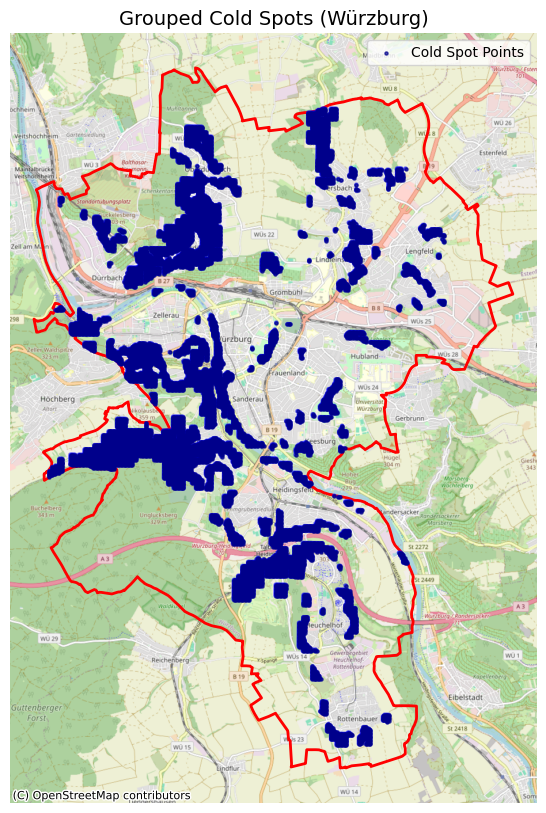

In [34]:
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx

# Prüfen, ob grouped_cold_spots existiert und nicht leer ist
print("Checking if 'grouped_cold_spots' exists and is not empty...")
if 'grouped_cold_spots' in locals() and not grouped_cold_spots.empty:
    print("'grouped_cold_spots' found and is not empty. Proceeding with visualization.")

    # Sicherstellen, dass alles in Web-Mercator (EPSG:3857) ist, da contextily es benötigt
    if grouped_cold_spots.crs is None or grouped_cold_spots.crs.to_string() != 'EPSG:3857':
        grouped_cold_spots_3857 = grouped_cold_spots.to_crs(epsg=3857)
    else:
        grouped_cold_spots_3857 = grouped_cold_spots

    if wuerzburg_grenze_gdf.crs is None or wuerzburg_grenze_gdf.crs.to_string() != 'EPSG:3857':
        wuerzburg_grenze_3857 = wuerzburg_grenze_gdf.to_crs(epsg=3857)
    else:
        wuerzburg_grenze_3857 = wuerzburg_grenze_gdf

    if 'cold_spots_p_filtered' in locals() and not cold_spots_p_filtered.empty:
        if cold_spots_p_filtered.crs is None or cold_spots_p_filtered.crs.to_string() != 'EPSG:3857':
            cold_spots_p_filtered_3857 = cold_spots_p_filtered.to_crs(epsg=3857)
        else:
            cold_spots_p_filtered_3857 = cold_spots_p_filtered
    else:
        cold_spots_p_filtered_3857 = None

    # --- Debugging: Check data before plotting ---
    print("\n--- Debugging Data ---")
    print("grouped_cold_spots_3857 head:")
    display(grouped_cold_spots_3857.head())
    print("\ngrouped_cold_spots_3857 CRS:", grouped_cold_spots_3857.crs)

    print("\nwuerzburg_grenze_3857 head:")
    display(wuerzburg_grenze_3857.head())
    print("\nwuerzburg_grenze_3857 CRS:", wuerzburg_grenze_3857.crs)

    if cold_spots_p_filtered_3857 is not None:
        print("\ncold_spots_p_filtered_3857 head:")
        display(cold_spots_p_filtered_3857.head())
        print("\ncold_spots_p_filtered_3857 CRS:", cold_spots_p_filtered_3857.crs)
    # --- End Debugging ---


    # Plotten
    fig, ax = plt.subplots(figsize=(10, 10))

    # Würzburg-Grenze
    wuerzburg_grenze_3857.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Würzburg Boundary')

    # Grouped cold spots
    grouped_cold_spots_3857.plot(ax=ax, facecolor='blue', alpha=0.5, edgecolor='blue', label='Grouped Cold Spots')

    # Punkte optional hinzufügen
    if cold_spots_p_filtered_3857 is not None:
        cold_spots_p_filtered_3857.plot(ax=ax, color='darkblue', markersize=5, alpha=0.7, label='Cold Spot Points')

    # Basemap (OpenStreetMap)
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    # Titel, Legende, Achsen
    ax.set_title("Grouped Cold Spots (Würzburg)", fontsize=14)
    ax.legend()
    ax.set_axis_off()

    plt.show()

else:
    print("The 'grouped_cold_spots' GeoDataFrame does not exist or is empty. Cannot visualize.")

hier werden im Vergleich zu den Cold Spots für das Gesamte Stadtgebiet, deutlich mehr Teile des bewohnten Stadtgebiets als Cold Spot klassifiziert, zb auch meiste Teile des Ringarks, Grünflächen am Hubland/Frauenland